# Analysis of Alpha Sweep with Fixed Epsilon=0.1 (May 15, 2026)

This notebook analyzes the alpha sweep for the `WeightedVCRepairer` where epsilon is fixed at 0.1.

In [3]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob

%matplotlib inline
sns.set_theme(style="whitegrid")

In [4]:
def load_results(base_path):
    results = []
    json_files = glob.glob(os.path.join(base_path, "**", "*.json"), recursive=True)
    
    for file_path in json_files:
        try:
            with open(file_path, 'r') as f_in:
                data = json.load(f_in)
                
                entry = {
                    'experiment_name': data.get('experiment_name'),
                    'dataset': data.get('dataset_name'),
                    'deletion_ratio': data.get('deletion_ratio', {}).get('ratio'),
                    'repair_runtime': data.get('runtimes', {}).get('repairing'),
                    'repaired_marginal_error': data.get('marginals_error', {}).get('repaired_avg'),
                    'repaired_tvd_2way': data.get('tvd_2way', {}).get('repaired_avg'),
                }
                
                ml_repaired = data.get('ml_accuracy', {}).get('repaired', {})
                if ml_repaired:
                    entry['ml_accuracy_mean'] = np.mean(list(ml_repaired.values()))
                
                name = entry['experiment_name']
                if name and ('weighted_alpha_eps01_v4' in name or 'weighted_updated_alpha_v4' in name):
                    parts = name.split('_')
                    # weighted_alpha_eps01_v4_dataset_model_a0.5
                    entry['model'] = parts[5]
                    entry['alpha'] = float(parts[6][1:])
                    entry['epsilon'] = 0.1
                
                results.append(entry)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            
    return pd.DataFrame(results)

base_path = os.path.join("..", "results_alpha_eps01", "results")
if not os.path.exists(base_path):
    base_path = os.path.join("results_alpha_eps01", "results")

print(f"Searching for results in: {os.path.abspath(base_path)}")
df = load_results(base_path)

if df.empty:
    print("Warning: No results loaded. Found 0 JSON files or failed to parse them.")
else:
    print(f"Loaded {len(df)} results.")
    display(df.head())

Searching for results in: c:\Users\itayc\OneDrive\Desktop\Master\final\results_alpha_eps01\results
Loaded 1530 results.


,experiment_name,dataset,deletion_ratio,repair_runtime,repaired_marginal_error,repaired_tvd_2way,ml_accuracy_mean,model,alpha,epsilon
0,alpha_sweep_may2026_adult_aim_classic_vc_a0.0,adult,0.11124,8437.372344,0.298895,0.051134,0.833463,NaN,NaN,NaN
1,alpha_sweep_may2026_adult_aim_classic_vc_a0.01,adult,0.11124,8511.998887,0.298895,0.051134,0.833463,NaN,NaN,NaN
2,alpha_sweep_may2026_adult_aim_classic_vc_a0.02,adult,0.11124,6780.023958,0.298895,0.051134,0.833463,NaN,NaN,NaN
3,alpha_sweep_may2026_adult_aim_classic_vc_a0.03,adult,0.11124,6728.253509,0.298895,0.051134,0.833463,NaN,NaN,NaN
4,alpha_sweep_may2026_adult_aim_classic_vc_a0.04,adult,0.11124,4524.490850,0.298895,0.051134,0.833463,NaN,NaN,NaN


In [5]:
df.columns

Index(['experiment_name', 'dataset', 'deletion_ratio', 'repair_runtime',
       'repaired_marginal_error', 'repaired_tvd_2way', 'ml_accuracy_mean',
       'model', 'alpha', 'epsilon'],
      dtype='object')

## Alpha Analysis (eps=0.1)

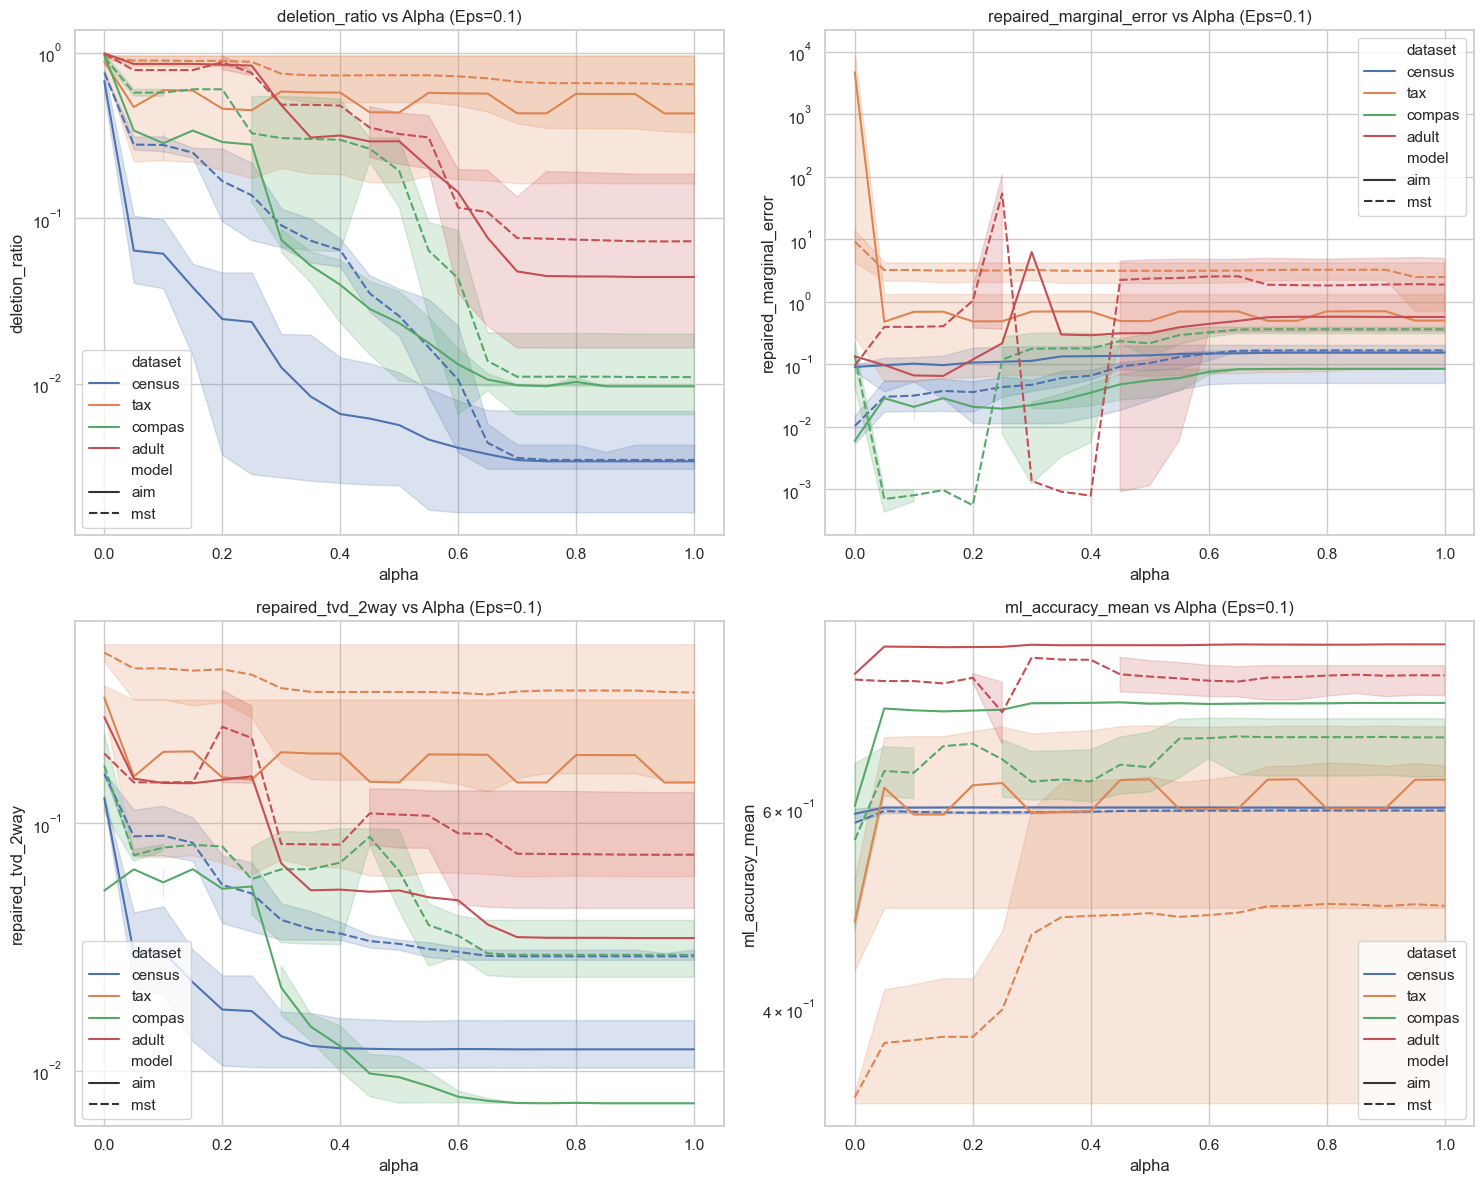

In [ ]:
if not df.empty and 'alpha' in df.columns:
    plot_df = df.sort_values('alpha')
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    metrics = ['deletion_ratio', '', 'repaired_tvd_2way', 'ml_accuracy_mean']
    
    for i, metric in enumerate(metrics):
        if metric in plot_df.columns:
            ax = axes[i//2, i%2]
            sns.lineplot(data=plot_df, x='alpha', y=metric, hue='dataset', style='model', ax=ax)
            ax.set_title(f'{metric} vs Alpha (Eps=0.1)')
            ax.set_yscale('log')
    plt.tight_layout()
    plt.show()